# **ARIMA - TimeSeries Based Algo**

In [1]:
!pip install pandas numpy statsmodels scikit-learn matplotlib

Missing values: passengers    0
dtype: int64
Outliers: Empty DataFrame
Columns: [passengers]
Index: []


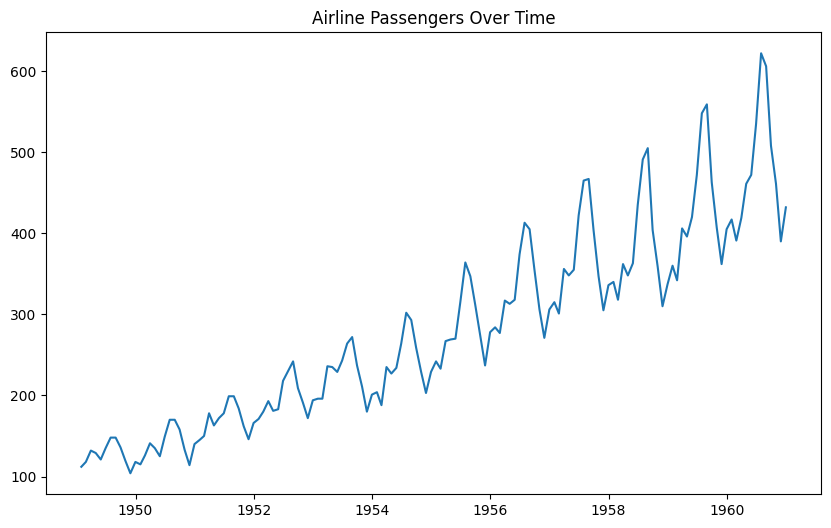

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Series is not stationary, differencing needed.
Differenced ADF Statistic: -2.8292668241700047
Differenced p-value: 0.05421329028382478


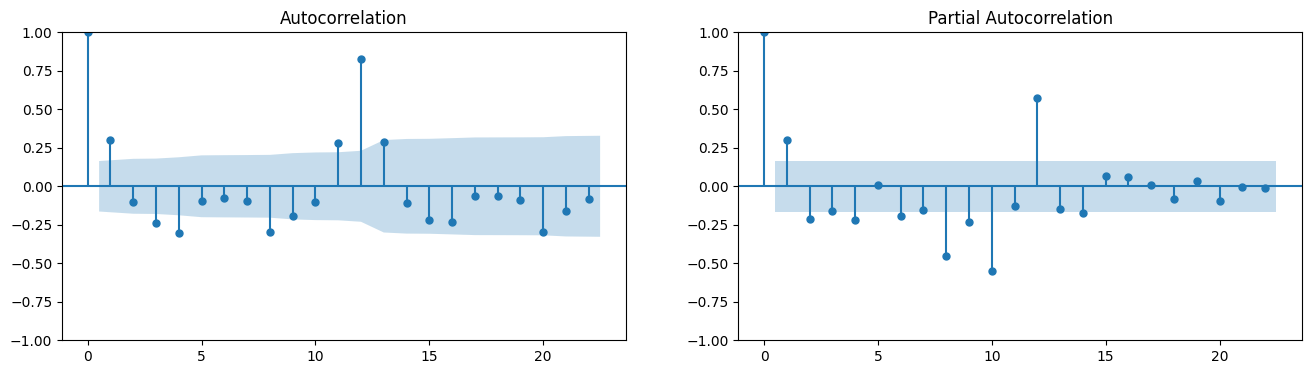

                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -694.341
Date:                Fri, 30 Jan 2026   AIC                           1394.683
Time:                        19:01:39   BIC                           1403.571
Sample:                    01-31-1949   HQIC                          1398.294
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4742      0.123     -3.847      0.000      -0.716      -0.233
ma.L1          0.8635      0.078     11.051      0.000       0.710       1.017
sigma2       961.9270    107.433      8.954      0.0

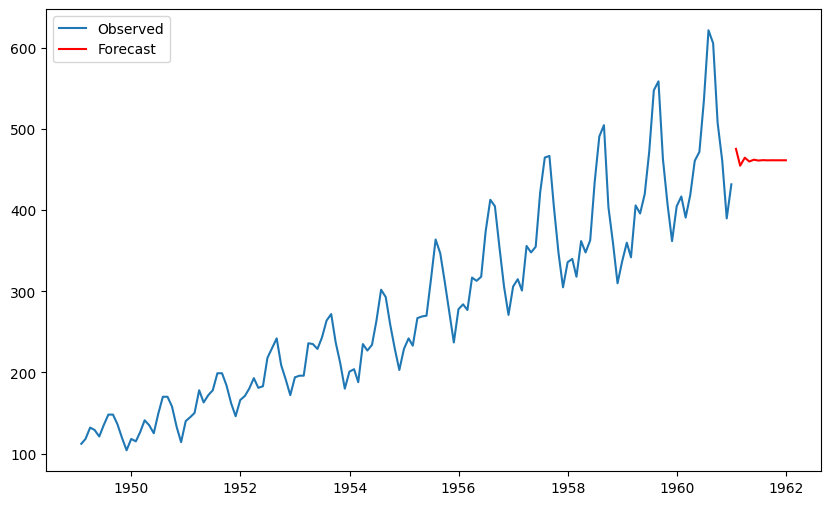

Mean Squared Error: 9506.17584193304


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.datasets import get_rdataset

import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Load sample dataset (Airline Passengers)
data = get_rdataset('AirPassengers').data
df = pd.DataFrame(data)
df['time'] = pd.date_range(start='1949-01', periods=len(df), freq='M')
df.set_index('time', inplace=True)
df.rename(columns={'value': 'passengers'}, inplace=True)

# Data Cleaning
# Check for missing values
print("Missing values:", df.isnull().sum())

# Handle missing values (if any, fill with forward fill)
df = df.fillna(method='ffill')



# Check for outliers (simple IQR method)
Q1 = df['passengers'].quantile(0.25)
Q3 = df['passengers'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['passengers'] < lower_bound) | (df['passengers'] > upper_bound)]
print("Outliers:", outliers)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.plot(df['passengers'])
plt.title('Airline Passengers Over Time')
plt.show()

# Check stationarity with Augmented Dickey-Fuller test
result = adfuller(df['passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] > 0.05:
    print("Series is not stationary, differencing needed.")
    df['passengers_diff'] = df['passengers'].diff()
    # Re-check stationarity on differenced data
    result_diff = adfuller(df['passengers_diff'].dropna())
    print('Differenced ADF Statistic:', result_diff[0])
    print('Differenced p-value:', result_diff[1])
else:
    df['passengers_diff'] = df['passengers']

# Plot ACF and PACF for differenced data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['passengers_diff'].dropna(), ax=ax1)
plot_pacf(df['passengers_diff'].dropna(), ax=ax2)
plt.show()

# Fit ARIMA model (assume p=1, d=1, q=1 based on common values; adjust as needed)
model = ARIMA(df['passengers'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Forecast
forecast_steps = 12
forecast = model_fit.forecast(steps=forecast_steps)
plt.figure(figsize=(10, 6))
plt.plot(df['passengers'], label='Observed')
plt.plot(pd.date_range(start=df.index[-1], periods=forecast_steps+1, freq='M')[1:], forecast, label='Forecast', color='red')
plt.legend()
plt.show()

# Evaluate (using train-test split)
train_size = int(len(df) * 0.8)
train, test = df['passengers'][:train_size], df['passengers'][train_size:]
model_eval = ARIMA(train, order=(1, 1, 1)).fit()
predictions = model_eval.forecast(steps=len(test))
mse = mean_squared_error(test, predictions)
print('Mean Squared Error:', mse)